In [2]:
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter
from IPython.display import Video
import jax.numpy as jnp
import jax.lax as lax
import jax
from functools import partial

from typing import Callable, List

In [3]:
key = jax.random.key(123)
key, key_ = jax.random.split(key)

In [4]:

# Basic metropolis algorithm
@partial(jax.jit, static_argnums=(2,3))
def metropolis_kernel(proposal_key, acceptance_key, target, proposal, q):
    # Sample q' ~ proposal(q'|q)
    q_proposed = proposal(proposal_key, q) # q'
    acceptance_ratio = target(q_proposed)/target(q)
    return jax.lax.select(jax.random.uniform(acceptance_key) < acceptance_ratio, q_proposed, q)

def metropolis(key: jax.Array, target: Callable[[float], float], initial: jax.Array, proposal: Callable[[float], float], iterations=100_000):
    samples: List[float] = [initial]
    key, *proposal_keys = jax.random.split(key, num=iterations+1)
    key, *acceptance_keys = jax.random.split(key, num=iterations+1)

    for i in range(iterations):
        q = samples[-1] # q
        q_prime = metropolis_kernel(proposal_keys[i], acceptance_keys[i], target, proposal, q)
        samples += [q_prime]
    return jnp.array(samples)

In [5]:
class NormalProposal:
    def __init__(self, scale):
        self.scale = scale
    
    def __call__(self, key, q):
        z = jax.random.normal(key, q.shape)
        return z * self.scale + q

In [6]:
class DonutPDF():
    def __init__(self, radius=3, var=0.05):
        self.radius = radius
        self.var = var
    
    def __call__(self, x):
        r = jnp.linalg.norm(x)
        return jnp.exp((-(r - self.radius)**2)/self.var)
    
    @partial(jax.jit, static_argnums=(0,))
    def log_density(self, x):
        r = jnp.linalg.norm(x)
        return -((r - self.radius) ** 2) / self.var

    @partial(jax.jit, static_argnums=(0,))
    def grad_log_density(self, x):
        r = jnp.linalg.norm(x)
        return jnp.where(r == 0, jnp.zeros_like(x), 2 * x * (self.radius / r - 1) / self.var)

In [7]:
class HeartPDF():
    def __init__(self, radius=3, var=0.05):
        self.radius = radius
        self.var = var
    
    def __call__(self, x):
        r = jnp.linalg.norm(x)
        #return jnp.exp((-(r - self.radius)**2)/self.var)
        return jnp.exp((-((x[0]**2 + x[1]**2 - 1)**3 - x[0]**2*x[1]**3)**2)/self.var)
    
    @partial(jax.jit, static_argnums=(0,))
    def log_density(self, x):
        r = jnp.linalg.norm(x)
        return (-((x[0]**2 + x[1]**2 - 1)**3 - x[0]**2*x[1]**3)**2)/self.var

    @partial(jax.jit, static_argnums=(0,))
    def grad_log_density(self, x):
        return jax.grad(self.log_density)(x)

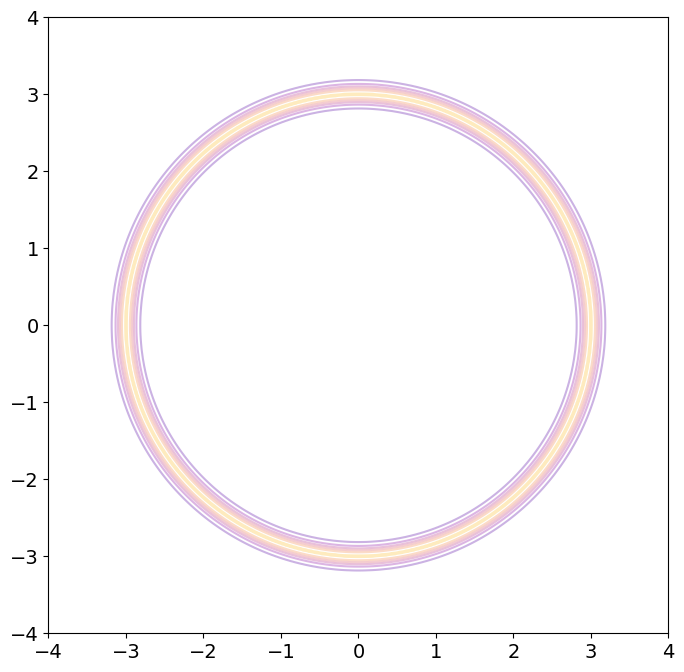

In [12]:
target = DonutPDF(var=0.02)
f = plt.figure(figsize=(8, 8))
ax = plt.gca()
ax.tick_params('both', which='major', labelsize=14)

points = jnp.linspace(-4, 4, 500)
x = jnp.tile(points, len(points))
y = jnp.repeat(points, len(points))

z = jnp.exp(jnp.apply_along_axis(target, 1, jnp.column_stack([x, y])))

ax.contour(
    points,
    points,
    z.reshape(len(points), len(points)),
    cmap="plasma",
    alpha=0.3,
    levels=5,
)

In [15]:
target = DonutPDF(var=5e-2)
samples05 = metropolis(key, target, jnp.array([0,1], dtype=float), NormalProposal(0.01), iterations=10_000)
samples1 = metropolis(key, target, jnp.array([0,1], dtype=float), NormalProposal(0.1), iterations=10_000)

TypeError: cannot unpack non-iterable PathCollection object

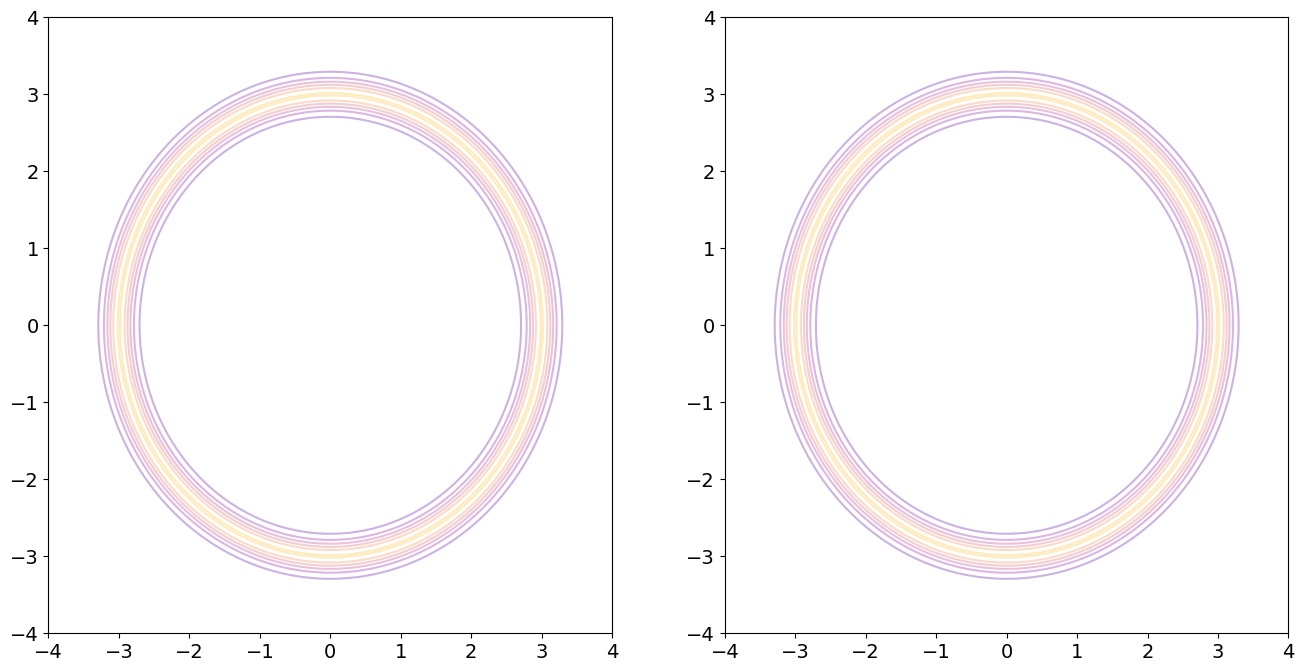

In [17]:
import jax.version


f, ax = plt.subplots(figsize=(16, 8), ncols=2)
ax[0].tick_params('both', which='major', labelsize=14)
ax[1].tick_params('both', which='major', labelsize=14)

points = jnp.linspace(-4, 4, 301)
x = jnp.tile(points, len(points))
y = jnp.repeat(points, len(points))

z = jnp.exp(jnp.apply_along_axis(target, 1, jnp.column_stack([x, y])))

ax[0].contour(
    points,
    points,
    z.reshape(len(points), len(points)),
    cmap="plasma",
    alpha=0.3,
    levels=5,
)

ax[1].contour(
    points,
    points,
    z.reshape(len(points), len(points)),
    cmap="plasma",
    alpha=0.3,
    levels=5,
)

(traj05,) = ax[0].plot([], [])
(traj1,) = ax[1].plot([], [])

title05 = ax[0].set_title("Acceptance rate: ", fontsize=18)
title1 = ax[1].set_title("Acceptance rate: ", fontsize=18)

writer = FFMpegWriter(fps=25)

@jax.jit
def compare_mean(array1, array2):
    return 1 - jnp.all(array1 == array2, axis=1).mean()

with writer.saving(f, "donut_mcmc.mp4", 50):
    # initial empty frames
    for _ in range(25):
        writer.grab_frame()

    for i in range(2, 2500, 2):
        traj05.set_data(*(samples05[: i + 1].T))
        traj1.set_data(*(samples1[: i + 1].T))

        accept05 = 1 - (samples05[1 : i + 1] == samples05[:i]).all(axis=1).mean()
        accept1 = 1 - (samples1[1 : i + 1] == samples1[:i]).all(axis=1).mean()
        title05.set_text(f"Acceptance rate: {accept05 * 100:.1f}%")
        title1.set_text(f"Acceptance rate: {accept1 * 100:.1f}%")

        writer.grab_frame()

    # closing empty frames
    for _ in range(25):
        writer.grab_frame()

plt.savefig("metropolis-snapshot.png")
plt.close()

In [ ]:
Video("donut_mcmc.mp4")

In [8]:
def leapfrog_step(q,p, acc, i, target,step_size):
    p = p + target.grad_log_density(q) * step_size / 2
    q = q + p * step_size
    p = p + target.grad_log_density(q) * step_size / 2
    return q, p, acc.at[i].set(q)

@partial(jax.jit, static_argnums=(2,3,4))
def leapfrog(q0, p0, target, L, step_size):
    return jax.lax.fori_loop(0,L, lambda i, x: leapfrog_step(x[0],x[1], x[2], i, target,step_size), (q0,p0, jnp.zeros((L, *q0.shape), dtype=float)))

In [9]:
leapfrog(jnp.array(0.2), jnp.array(3.2), target, 10, 1)

NameError: name 'target' is not defined

In [23]:
leapfrog(jnp.array(0.2), jnp.array(3.2), target, 10, 0.1)

(Array(0.312873, dtype=float32),
 Array(5.704072, dtype=float32),
 Array([1.08      , 2.728     , 4.4848    , 5.64768   , 5.7514877 ,
        4.7547007 , 3.0560334 , 1.334953  , 0.27989122, 0.312873  ],      dtype=float32))

In [10]:
@partial(jax.jit, static_argnums=(3,4,5))
def hmc_kernel(momentum_key, acceptance_key, q0, target, L, step_size):
    p0 = jax.random.normal(momentum_key, q0.size) # Sample momentum

    q_star, p_star, _ = leapfrog(q0, p0, target, L, step_size) # Integrate forward in phase space

    h0 = -target.log_density(q0) + (p0 * p0).sum() / 2 # Compute Hamiltonian energy from q
    h = -target.log_density(q_star) + (p_star * p_star).sum() / 2 # Compute Hamiltonian energy from q* (originally this uses a strange definition of hamiltonian energy)
    log_accept_ratio = h0 - h # in log space, so this is just acceptance ration
    return jnp.where(jax.random.uniform(acceptance_key) < jnp.exp(log_accept_ratio), q_star, q0) 

def hmc(key, target, initial, iterations=10_000, L=50, step_size=0.1):
    samples = [initial()]
    key, *momentum_keys = jax.random.split(key, num=iterations+1)
    key, *acceptance_keys = jax.random.split(key, num=iterations+1)
    for i in range(iterations):
        q0 = samples[-1]
        q_prime = hmc_kernel(momentum_keys[i], acceptance_keys[i], q0, target, L, step_size)
        samples.append(q_prime)

    return jnp.array(samples)

In [27]:
key, key_ = jax.random.split(key)
hmc_samples = hmc(key_, DonutPDF(var=2e-2), lambda: jnp.array([0.0, 1.0]), step_size=0.01)

In [85]:
f, ax = plt.subplots(figsize=(7, 7))

points = jnp.linspace(-2, 2, 101)
x = jnp.tile(points, len(points))
y = jnp.repeat(points, len(points))

heart = HeartPDF(var=5e-3)
z = jnp.exp(jnp.apply_along_axis(heart.log_density, 1, jnp.column_stack([x, y])))

ax.contour(
    points,
    points,
    z.reshape(len(points), len(points)),
    cmap="plasma",
    alpha=0.5,
)

(samps,) = ax.plot([], [], "o", alpha=0.7)
(traj,) = ax.plot([], [], "k")

writer = FFMpegWriter(fps=15)

with writer.saving(f, "heart_hmc.mp4", 50):
    # initial empty frame
    writer.grab_frame()

    samples = [jnp.array([0.0, 1.0])]
    samps.set_data(*(jnp.array(samples).T))

    writer.grab_frame()

    for i in range(100):
        q0 = samples[-1]
        key, key_ = jax.random.split(key)
        p0 = 2*jax.random.normal(key_, q0.shape)

        q_star, p_star, trajectory = leapfrog(q0, p0, heart, 40, 0.01)

        h0 = -heart.log_density(q0) + (p0 * p0).sum() / 2
        h = -heart.log_density(q_star) + (p_star * p_star).sum() / 2
        log_accept_ratio = h0 - h

        # animate the trajectory
        for j in range(len(trajectory)):
            traj.set_data(*jnp.array(trajectory[: j + 1]).T)
            writer.grab_frame()

        # flash green or red to signal acceptance / rejection
        key, key_ = jax.random.split(key)
        if jax.random.uniform(key_) < jnp.exp(log_accept_ratio):
            samples.append(q_star)
            traj.set_color("tab:green")
        else:
            samples.append(q0)
            traj.set_color("tab:red")

        for _ in range(2):
            writer.grab_frame()

        traj.set_color("black")
        traj.set_data([], [])
        samps.set_data(*(jnp.array(samples).T))
        writer.grab_frame()

plt.savefig("hmc-snapshot.png")
plt.close()

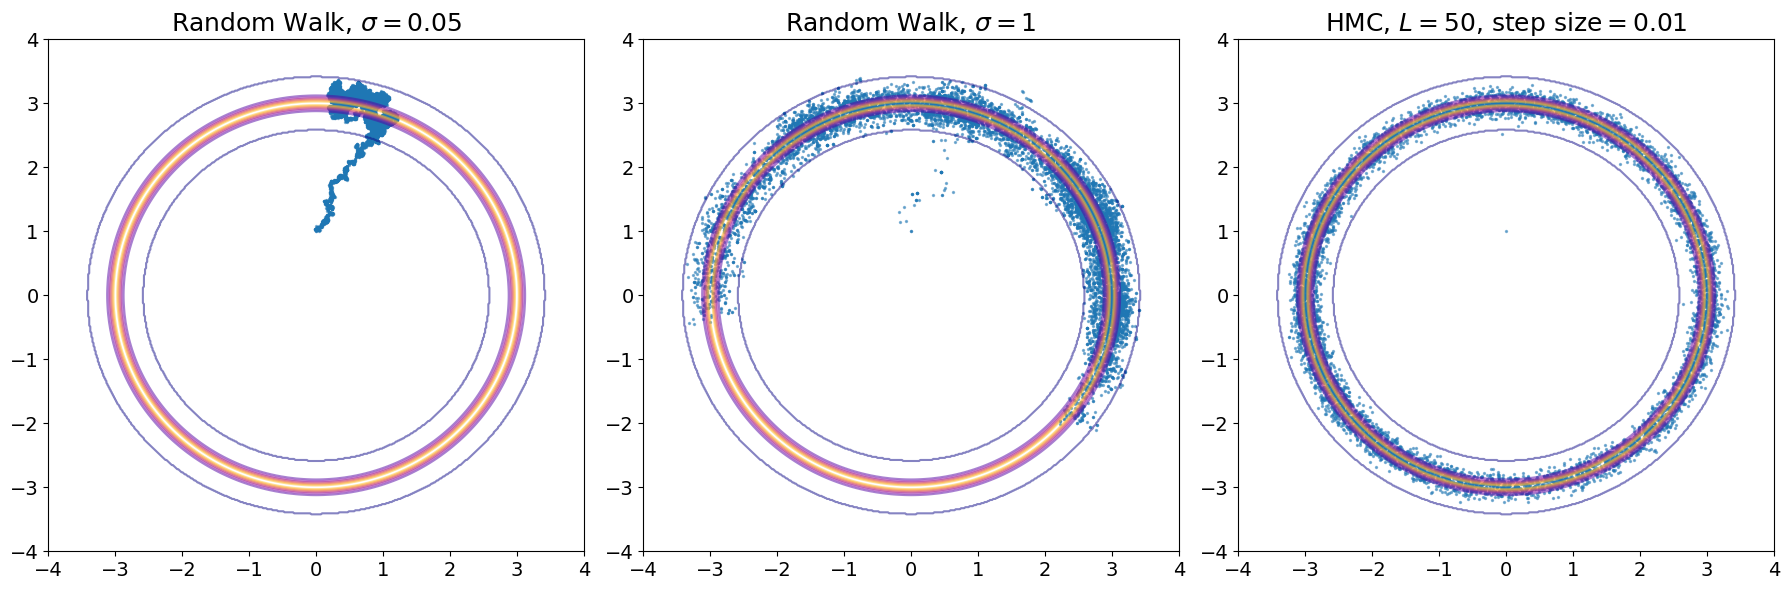

In [44]:
f, axs = plt.subplots(figsize=(18, 6), ncols=3)
target = DonutPDF(var=1e-2)
axs = axs.ravel()
points = jnp.linspace(-4, 4, 500)
x = jnp.tile(points, len(points))
y = jnp.repeat(points, len(points))

z = jnp.exp(jnp.apply_along_axis(target, 1, jnp.column_stack([x, y])))
for ax in axs:
    ax.tick_params('both', which='major', labelsize=14)
    ax.contour(
        points,
        points,
        z.reshape(len(points), len(points)),
        cmap="plasma",
        alpha=0.5,
    )
axs[0].scatter(*samples05.T, alpha=0.5, s=2)
axs[0].set_title("Random Walk, $\sigma=0.05$", fontsize=18)
axs[1].scatter(*samples1.T, alpha=0.5, s=2)
axs[1].set_title("Random Walk, $\sigma=1$", fontsize=18)
axs[2].scatter(*hmc_samples.T, alpha=0.5, s=2)
axs[2].set_title(r"HMC, $L=50$, step size$=0.01$", fontsize=18)
f.tight_layout()
f.savefig("mcmc-comparison.png")

In [11]:
import time
from tqdm import trange
class GaussianPDF():
    def __init__(self, var=0.05):
        self.var = var
    
    def __call__(self, x):
        return jax.scipy.stats.norm.pdf(x, loc=0, scale=jnp.sqrt(self.var))
    
    @partial(jax.jit, static_argnums=(0,))
    def log_density(self, x):
        return jax.scipy.stats.norm.logpdf(x, loc=0, scale=jnp.sqrt(self.var))

    @partial(jax.jit, static_argnums=(0,))
    def grad_log_density(self, x):
        return jax.grad(jax.scipy.stats.multivariate_normal.logpdf)(x, mean=jnp.zeros_like(x), cov=jnp.sqrt(self.var)*jnp.eye(x.shape[0]))

def get_init(key, dim):
    return jax.random.normal(key, (dim,))

results = []
for i in trange(1,200,5):
    key, key_, key__ = jax.random.split(key, 3)
    b = time.time()
    hmc(key_, GaussianPDF(var=5), lambda: get_init(key__, i), step_size=0.01)
    a = time.time()
    results.append({
        "delta": a - b
    })

  0%|          | 0/40 [00:00<?, ?it/s]

100%|██████████| 40/40 [19:33<00:00, 29.33s/it]


In [12]:
print(results)

[{'delta': 3.3312506675720215}, {'delta': 3.6871531009674072}, {'delta': 3.86248779296875}, {'delta': 4.535269737243652}, {'delta': 4.932072162628174}, {'delta': 5.609732389450073}, {'delta': 6.351325035095215}, {'delta': 7.1363983154296875}, {'delta': 8.068258047103882}, {'delta': 8.585588693618774}, {'delta': 9.04521131515503}, {'delta': 10.068317651748657}, {'delta': 11.952615976333618}, {'delta': 11.307084798812866}, {'delta': 13.547956705093384}, {'delta': 14.695116996765137}, {'delta': 15.729773998260498}, {'delta': 17.42724585533142}, {'delta': 20.56112003326416}, {'delta': 17.899433612823486}, {'delta': 21.974904537200928}, {'delta': 23.991278886795044}, {'delta': 27.880760669708252}, {'delta': 28.286920309066772}, {'delta': 31.689847946166992}, {'delta': 34.60827589035034}, {'delta': 33.463457107543945}, {'delta': 34.83007478713989}, {'delta': 40.1408486366272}, {'delta': 42.28173327445984}, {'delta': 49.42189574241638}, {'delta': 52.113603830337524}, {'delta': 51.125116586685

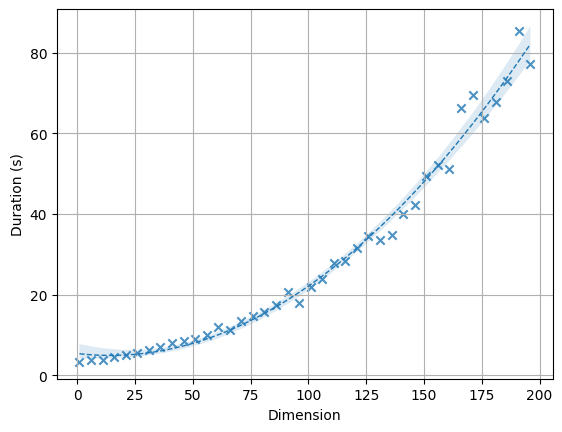

In [29]:
import pandas as pd
import seaborn as sns
df = pd.DataFrame(results)
df.index = range(1,200, 5)
df["dimension"] = df.index
#plt.plot(df.index.to_series(), df.delta, "x")
sns.regplot(df, x="dimension", y="delta", order=2, marker="x", line_kws={"linewidth": 1.0, "linestyle": "--"})
plt.xlabel("Dimension")
plt.ylabel("Duration (s)")
plt.grid()
plt.savefig("hmc-dimensions.png")

In [17]:
df["dimension"] = df.index

<Axes: xlabel='Depth', ylabel='Number of random variables'>

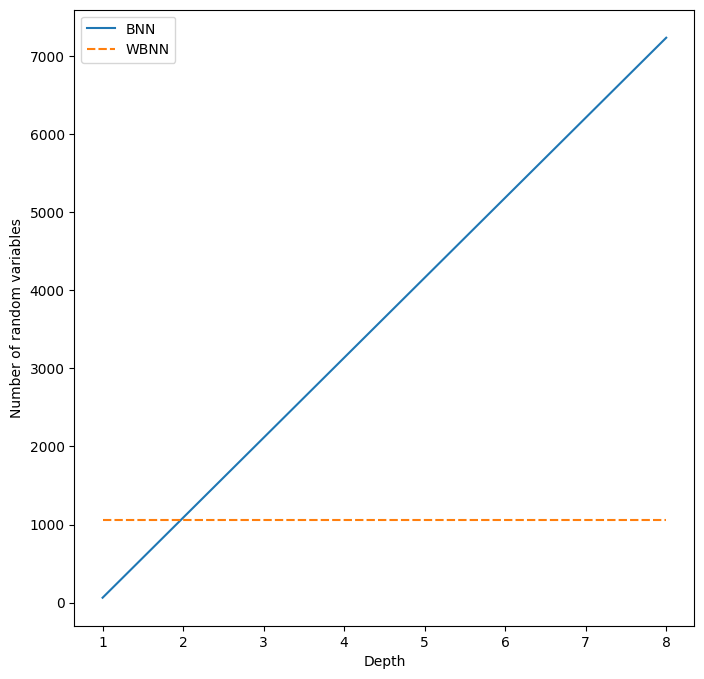

In [42]:
dicts = []
width = 32
for i in range(1,9):
    dicts += [{
        "BNN": 2*(width+1)+ (i-1)*width**2,
        "WBNN": (width+1)*width,
    }]
df = pd.DataFrame(dicts)
df.index = range(1,9)
fig = plt.figure(figsize=(8, 8))
ax = fig.gca()
ax.set_xlabel("Depth")
ax.set_ylabel("Number of random variables")
sns.lineplot(ax=ax,data=df)